5400
900
900
tensor(0.0029) tensor(0.0060)
<class 'torchvision.tv_tensors._image.Image'>
<class 'torchvision.tv_tensors._image.Image'>


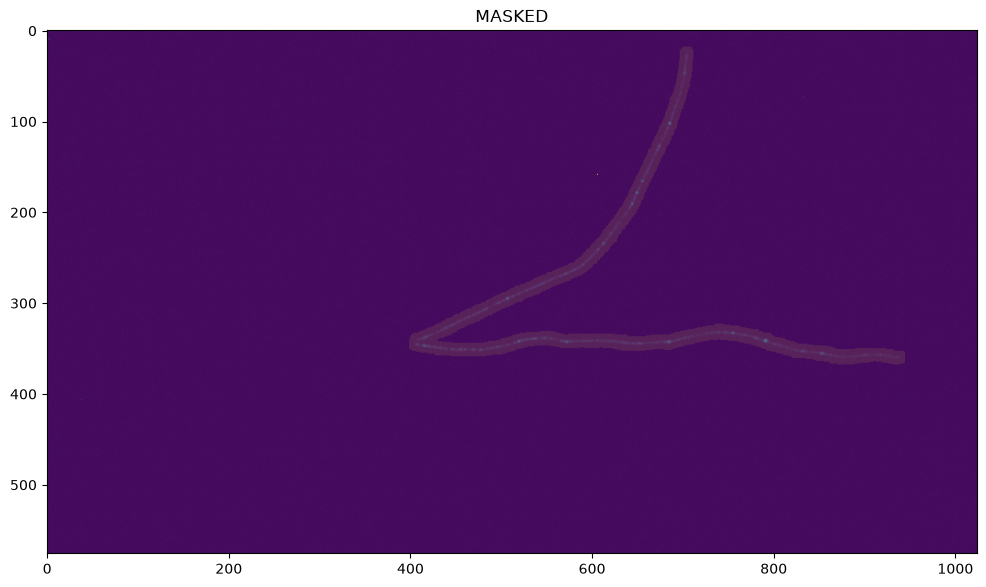

epoch 1 / 16
train loss = 0.0035361604842321305
vali loss = 0.00021703936207424185

Best validation loss: 0.00021703936207424185

Saving best model for epoch: 1

epoch 2 / 16
train loss = 0.00018843953416979362
vali loss = 0.0001541718091695137

Best validation loss: 0.0001541718091695137

Saving best model for epoch: 2

epoch 3 / 16
train loss = 0.00019080785614278284
vali loss = 0.00014317848503456583

Best validation loss: 0.00014317848503456583

Saving best model for epoch: 3

epoch 4 / 16
train loss = 0.00011982796829778679
vali loss = 0.00012006359403520557

Best validation loss: 0.00012006359403520557

Saving best model for epoch: 4

epoch 5 / 16
train loss = 0.0001066901387665504
vali loss = 0.0001881976926857273
epoch 6 / 16
train loss = 9.696025706164489e-05
vali loss = 0.00012294024470195706
epoch 7 / 16
train loss = 8.563670663923923e-05
vali loss = 8.687360916935307e-05

Best validation loss: 8.687360916935307e-05

Saving best model for epoch: 7

epoch 8 / 16
train loss = 

In [1]:
import cygnet, torch, os
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from torchvision.ops import sigmoid_focal_loss

# paths
train_path = "/home/frx/dataset/image_dataset/train"
vali_path = "/home/frx/dataset/image_dataset/vali"
test_path = "/home/frx/dataset/image_dataset/test"

# folders:
input_path = "input"
mask_path = "mask"
mask_exp2_path = "mask_exp2"
mask_exp4_path = "mask_exp4"

# change this
target_path = mask_exp4_path

input_train_path = os.path.join(train_path, input_path)
target_train_path = os.path.join(train_path, target_path)

input_vali_path = os.path.join(vali_path, input_path)
target_vali_path = os.path.join(vali_path, target_path)

input_test_path = os.path.join(test_path, input_path)
target_test_path = os.path.join(test_path, target_path)

train_dset = cygnet.CygnoSet(input_train_path, target_train_path)
print(len(train_dset))
vali_dset = cygnet.CygnoSet(input_vali_path, target_vali_path)
print(len(vali_dset))
test_dset = cygnet.CygnoSet(input_test_path, target_test_path)
print(len(test_dset))

image, mask = train_dset[1]

print(image.min(), image.max())
print(type(mask))
print(type(image))

cygnet.debug_plot(image.cpu().squeeze(), mask.cpu().squeeze(), vmin=None, vmax=None)

train_dloader = DataLoader(train_dset, batch_size=32, shuffle=True, num_workers=4, drop_last=True)
vali_dloader = DataLoader(vali_dset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
test_dloader = DataLoader(test_dset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

base = 16

net = cygnet.SkipNet(base).to(device)
opt = torch.optim.AdamW(net.parameters(), lr=1e-2, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.StepLR(opt, 3, gamma=0.5, last_epoch=-1)
saver = cygnet.SaveBestModel()

num_epochs = 16
train_loss_history = []
vali_loss_history = []

f_loss = sigmoid_focal_loss

for epoch in range(num_epochs):
	print(f"epoch {epoch+1} / {num_epochs}")
	
	net.train()
	train_loss = 0
	c = 0
	for imgs, masks in train_dloader:
		c += 1
		imgs  = imgs.to(device, non_blocking=True)
		masks = masks.to(device, non_blocking=True)
		opt.zero_grad(set_to_none=True)
		
		preds = net(imgs)

		loss = f_loss(preds, masks, reduction="mean")
		loss.backward()
		opt.step()
		train_loss += loss.item()
	
	train_loss /= c
	train_loss_history.append(train_loss)
	print(f"train loss = {train_loss}")
	
	net.eval()
	vali_loss = 0
	c = 0
	with torch.inference_mode():
		for imgs, masks in vali_dloader:
			c += 1
			imgs  = imgs.to(device, non_blocking=True)
			masks = masks.to(device, non_blocking=True)

			preds = net(imgs)

			vloss = f_loss(preds, masks, reduction="mean")
			vali_loss += vloss.item()
		vali_loss /= c
		vali_loss_history.append(vali_loss)
		print(f"vali loss = {vali_loss}")

	saver(vali_loss, epoch, net, opt, f_loss, base)
	
	scheduler.step()

[0.0035361604842321305, 0.00018843953416979362, 0.00019080785614278284, 0.00011982796829778679, 0.0001066901387665504, 9.696025706164489e-05, 8.563670663923923e-05, 8.375243331621667e-05, 8.055943806625909e-05, 7.745001602459178e-05, 7.472851139244172e-05, 7.373082492752776e-05, 7.086416482187425e-05, 7.034454216366049e-05, 6.96076404524536e-05, 6.879477434397683e-05]


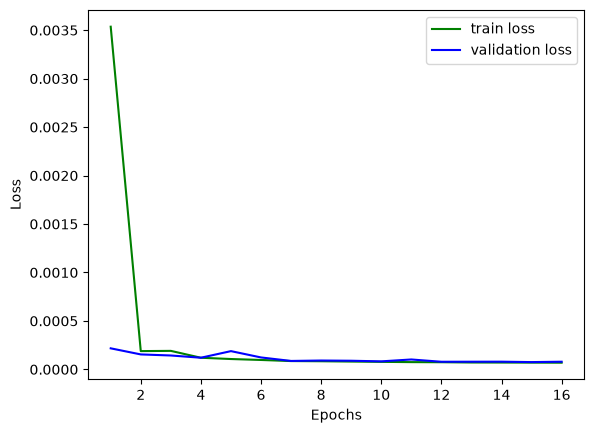

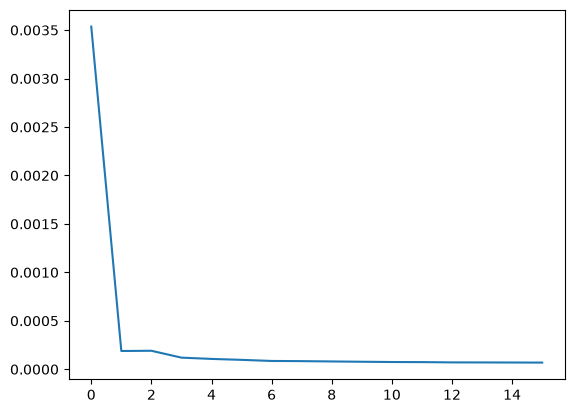

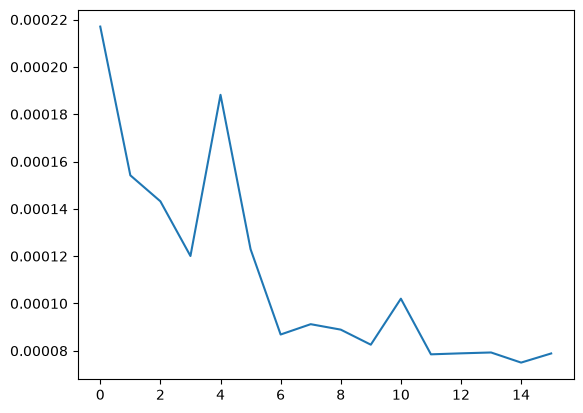

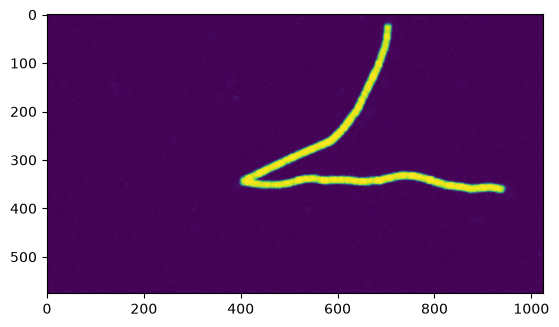

tensor(1.0000, device='cuda:0') tensor(0.0004, device='cuda:0')


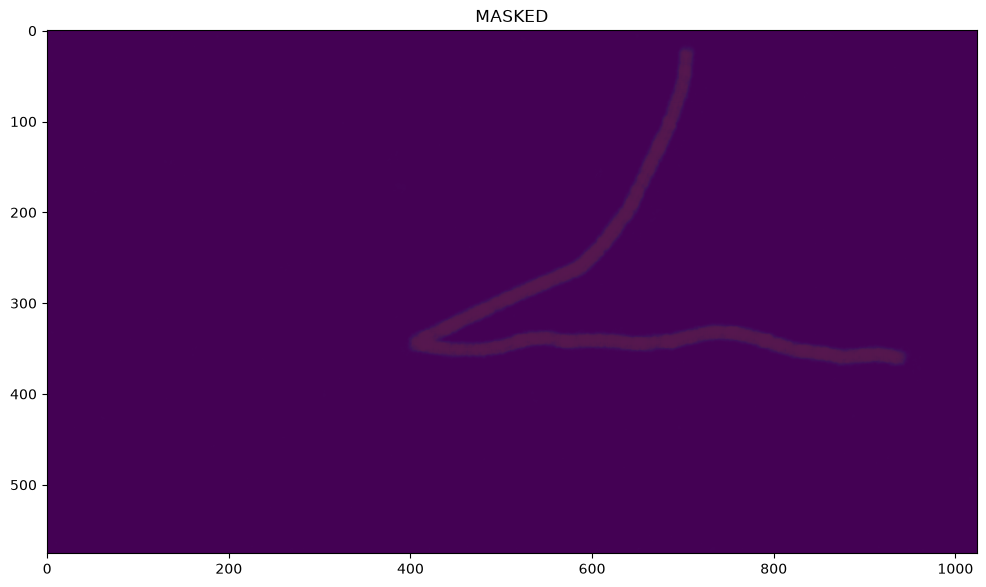

In [2]:
xt = [x for x in range(len(train_loss_history))]
xv = [x for x in range(len(vali_loss_history))]

print(train_loss_history)

net.eval()

plt.plot(range(1,len(train_loss_history)+1), train_loss_history, color='green', linestyle='-', label='train loss')
plt.plot(range(1,len(vali_loss_history)+1), vali_loss_history, color='blue', linestyle='-', label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.figure()
plt.plot(xt, train_loss_history)
plt.show()

plt.figure()
plt.plot(xv, vali_loss_history)
plt.show()
net.eval()

with torch.inference_mode():
	pred = net(image.unsqueeze(0).to(device))
pred = torch.sigmoid(pred)

plt.figure()
plt.imshow(pred.cpu().squeeze())
plt.show()

print(pred.max(), pred.min())
cygnet.debug_plot(image.cpu().squeeze(), pred.cpu().squeeze())

tensor(7.5209, device='cuda:0') tensor(-8.3044, device='cuda:0')
tensor(0.9995, device='cuda:0') tensor(0.0002, device='cuda:0')


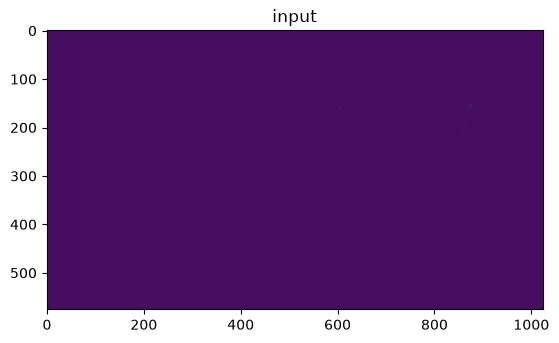

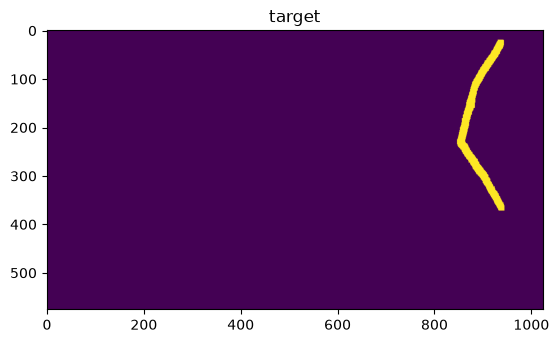

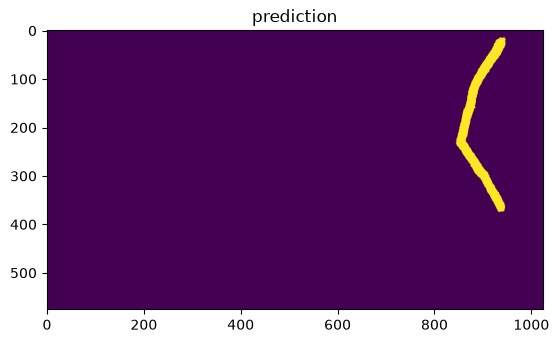

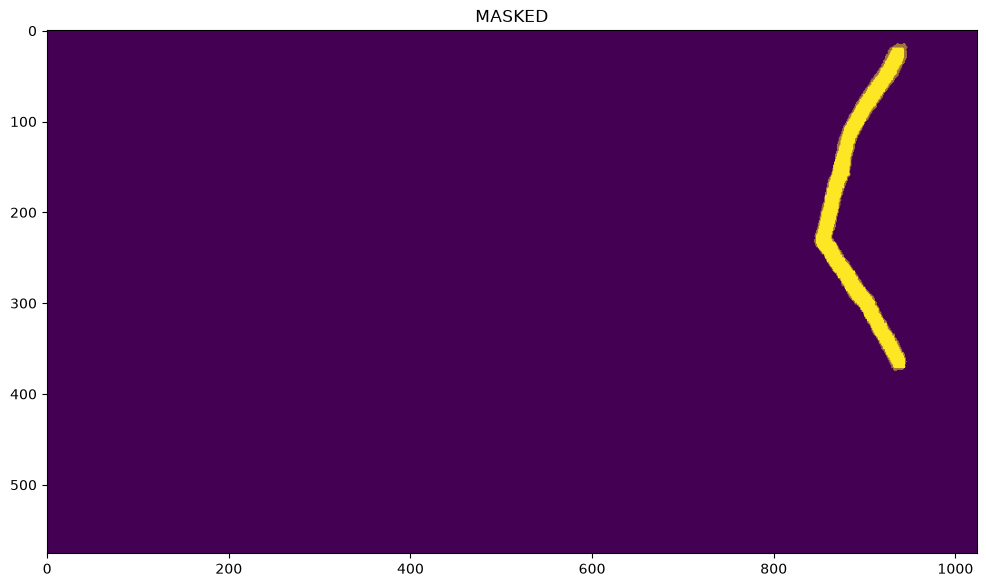

focal loss : 0.5405
recall     : 0.9998
precision  : 0.8321
compression: 1.3197%


In [3]:
def quickplot(img, title="img"):
	plt.figure()
	plt.imshow(img.cpu().squeeze())
	plt.title(title)
	plt.show()

ttt = 0.2

def evaluate(pred, mask, threshold=ttt):
	pred_prob = torch.sigmoid(pred)
	pred_mask = pred_prob > threshold
	true_mask = mask > 0.5

	tp = (pred_mask & true_mask).sum().item()
	fp = (pred_mask & ~true_mask).sum().item()
	fn = (~pred_mask & true_mask).sum().item()

	recall    = tp / (tp + fn + 1e-8)
	precision = tp / (tp + fp + 1e-8)
	compression = pred_mask.float().mean().item()
	loss = sigmoid_focal_loss(mask, pred, reduction="mean").item()

	print(f"focal loss : {loss:.4f}")
	print(f"recall     : {recall:.4f}")
	print(f"precision  : {precision:.4f}")
	print(f"compression: {compression:.4%}")

image, mask = test_dset[700]
net.eval()

with torch.inference_mode():
	pred = net(image.unsqueeze(0).to(device))
spred = torch.sigmoid(pred)
sspred = (spred > ttt).float()

print(pred.max(), pred.min())
print(spred.max(), spred.min())

quickplot(image, "input")
quickplot(mask, "target")
quickplot(sspred, "prediction")

cygnet.debug_plot(mask.squeeze(), sspred.cpu().squeeze(), 0.5, None, None)

evaluate(pred.cpu().squeeze(), mask.cpu().squeeze())



In [4]:
save = False

if save:
	torch.save({'model' : net,
		'epoch': epoch+1,
		'model_state_dict': net.state_dict(),
		'optimizer_state_dict': opt.state_dict(),
		'loss': sigmoid_focal_loss,
		}, 'saved_models/best_model_base16_res_drop.pt')